In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
stroke_data = pd.read_csv('../../data/raw/healthcare-dataset-stroke-data.csv')
stroke_data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [15]:
stroke_data.shape

(5110, 12)

In [14]:
stroke_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [45]:
# Rename column to be consistent
stroke_data = stroke_data.rename(
    columns = {
        'Residence_type': 'residence_type'
    }
)

# Drop unnecessary column
stroke_data = stroke_data.drop(columns=['id'])

stroke_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   str    
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 439.3 KB


In [46]:
stroke_data.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [47]:
# Check for null values
stroke_data.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [57]:
result = stroke_data.groupby('age')['stroke'].sum()
print(result)

age
0.08      0
0.16      0
0.24      0
0.32      0
0.40      0
         ..
78.00    21
79.00    17
80.00    17
81.00    14
82.00     9
Name: stroke, Length: 104, dtype: int64


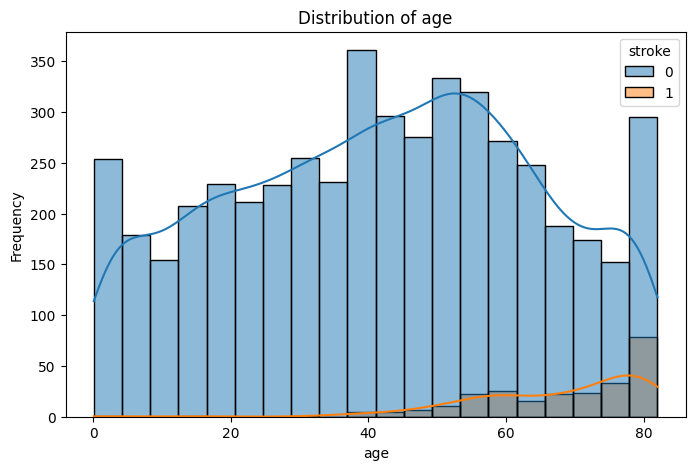

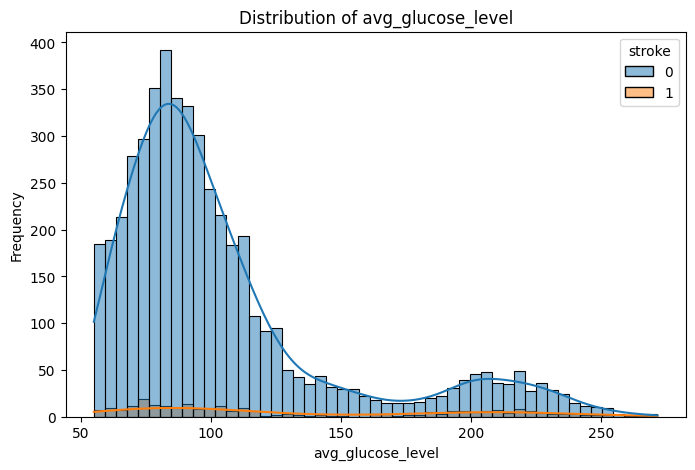

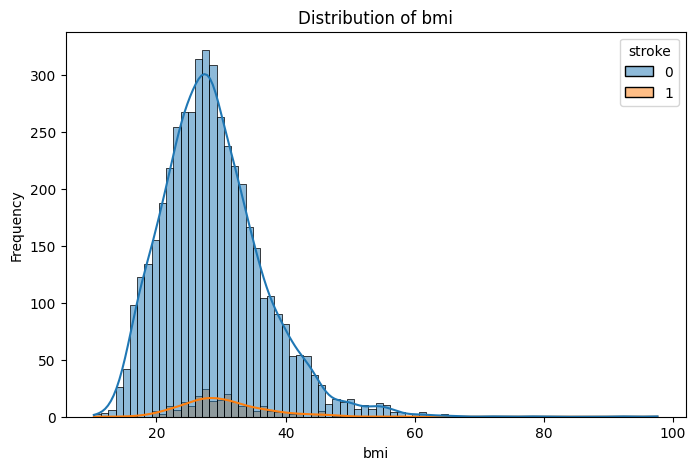

In [80]:
# Make copy of the dataset
stroke_df = stroke_data.copy()

# Statistics on Numerical Features (values that are float64)
numerical_cols = ['age', 'avg_glucose_level', 'bmi']

for col in numerical_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(x=stroke_df[col], data=stroke_df, hue='stroke', kde = True)
    #sns.histplot(stroke_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

In [66]:
result = stroke_df.groupby('gender')['stroke'].sum()
print(result)

gender
Female    141
Male      108
Other       0
Name: stroke, dtype: int64


In [82]:
result = stroke_df.groupby('stroke')['age'].mean()
print(result)

stroke
0    41.971545
1    67.728193
Name: age, dtype: float64


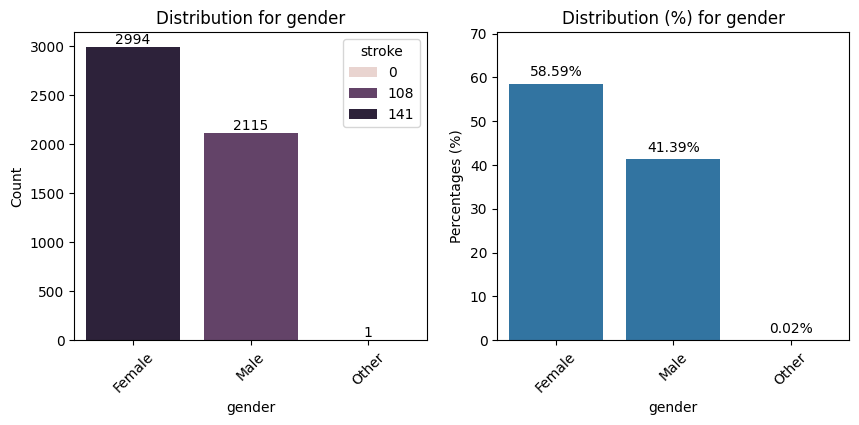

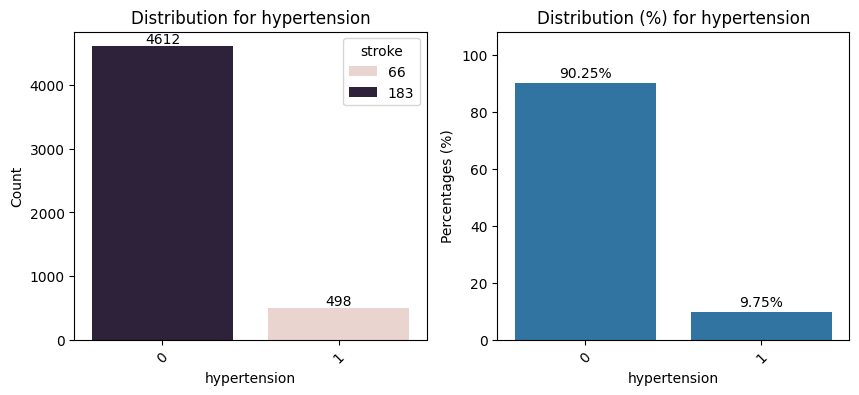

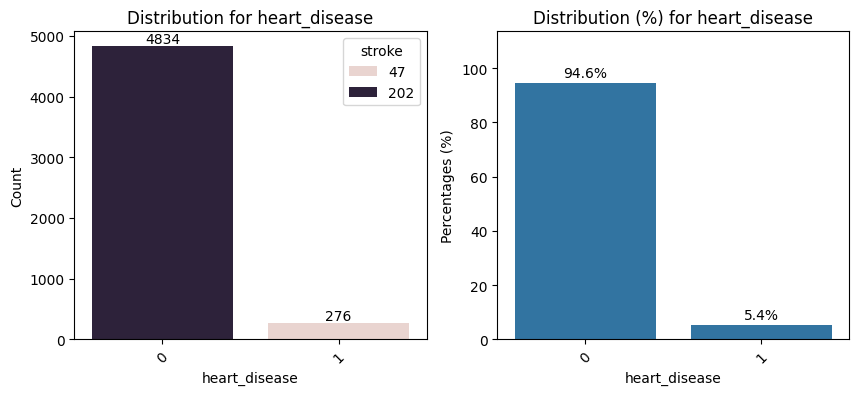

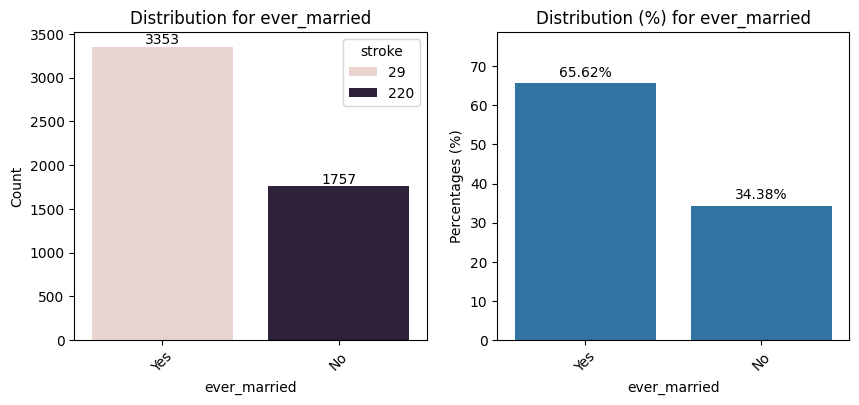

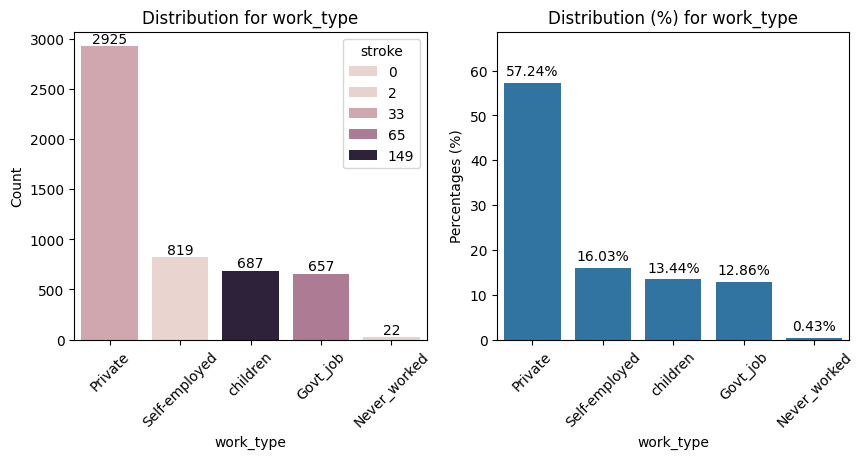

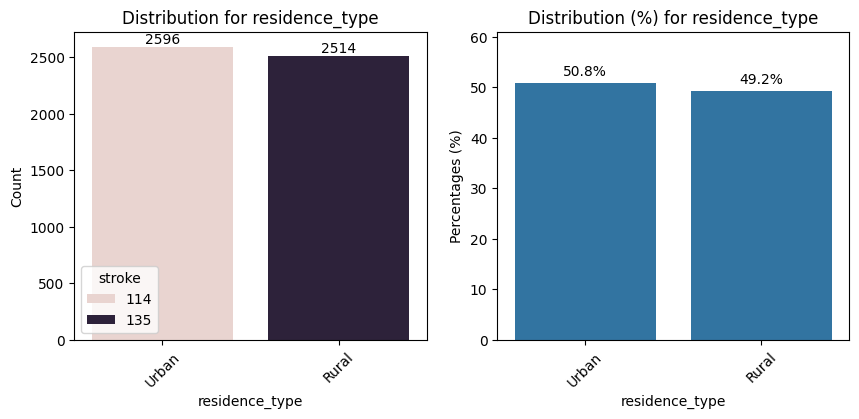

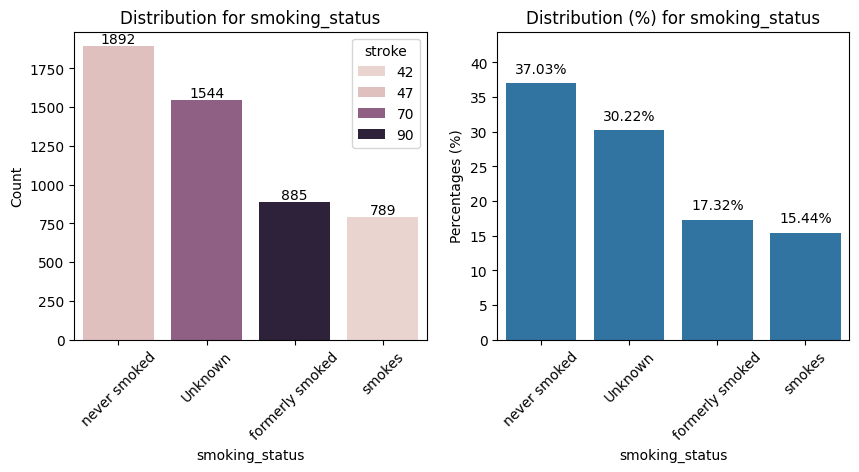

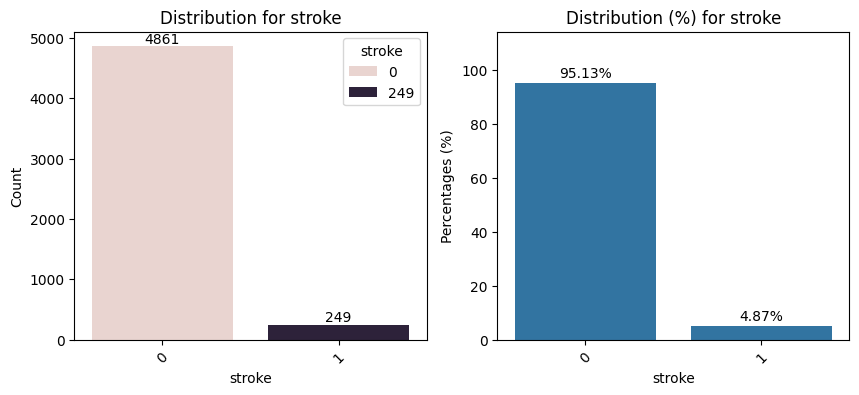

In [74]:
# Statistics on Categorical columns
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type',
                    'residence_type', 'smoking_status', 'stroke']

for col in categorical_cols:
    # Create a figure and a set of subplots (1 row, 2 columns)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

    # Plot on the first axes
    cat_count = stroke_df[col].value_counts()
    stroke_count = pd.DataFrame(stroke_df.groupby(col)['stroke'].sum())
    sns.barplot(
        x=cat_count.index,
        y=cat_count.values,
        ax=ax1,
        data=stroke_count,
        hue='stroke'
    )

    # Add count labels on each bar
    for i, value in enumerate(cat_count.values):
        ax1.text(
            i, value + 1, f'{value}',
            ha='center', va='bottom', fontsize=10
        )
    ax1.set_title(f'Distribution for {col}')
    ax1.set_xlabel(col)
    ax1.set_xticks(ticks=cat_count.index)
    ax1.set_xticklabels(labels=cat_count.index, rotation=45)
    ax1.set_ylabel('Count')

    # Compute percentages
    percentages = (stroke_df[col].value_counts(normalize=True) * 100).round(2)
    sns.barplot(
        x=percentages.index,
        y=percentages.values,
        ax=ax2
    )

    # Add percentage labels to each bar
    for i, value in enumerate(percentages.values):
        ax2.text(
            i, value + 1, f'{value}%',
            ha='center', va='bottom', fontsize=10
        )
    ax2.set_title(f'Distribution (%) for {col}')
    ax2.set_xlabel(col)
    ax2.set_ylabel('Percentages (%)')
    ax2.set_xticks(ticks=percentages.index)
    ax2.set_xticklabels(labels=percentages.index, rotation=45)
    ax2.set_ylim(0, max(percentages.values) * 1.2) # margin above bars

    # Display the plots
    plt.show()


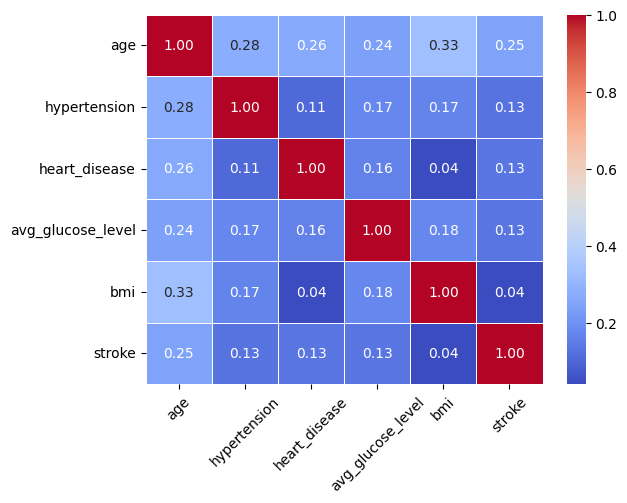

In [50]:
# Heat map of numberical features
corr = stroke_df.corr(numeric_only=True)

sns.heatmap(
    data=corr, 
    annot=True, 
    linewidth=0.5, 
    fmt='.2f', 
    cmap='coolwarm'
    )
plt.xticks(rotation=45)
plt.show()